## Redes clasificación Wine-red
_Ejemplo_ Wine quality-red
Tratar de predecir si un vino es de calidad alta (7), o no (resto de calidades) utilizando redes neuronales
Aplicar selectKbest como selector de 4 variables input candidatas

In [2]:
#importar las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import seaborn as sns
import plotly.graph_objects as go
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer, Binarizer, RobustScaler, label_binarize
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, PowerTransformer
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.tree import DecisionTreeClassifier, export_text, DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

In [4]:
seed=12345 #fijamos la semilla de aleatorización para que sea la misma en todo el proceso
#Reemplaza con la ruta correcta y nombre de tu archivo
file_path = '/Users/biblioadmin/Library/CloudStorage/OneDrive-UniversidadComplutensedeMadrid(UCM)/Documentos/Titulo Propio/Machine Learning/Redes Neuronales/Python/Datasets/winequality-red.csv' 
#convertir a data frame el archivo
df = pd.read_csv(file_path,sep=";")
print(f'\n Instancias: {df.shape[0]}; Variables: {df.columns}')
#La variable de interés es chd, binaria Si/No
#analizamos la frecuencia de cada clase
print(f'\n Instancias: {df.shape[0]}; Variables: {df.shape[1]}')
print(f'\nLa frecuencia de cada clase es: \n{df.quality.value_counts()}')


 Instancias: 1599; Variables: Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

 Instancias: 1599; Variables: 12

La frecuencia de cada clase es: 
quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


In [6]:
# Definimos una variable respuesta highQuality a partir de quality
df['highQuality'] = df['quality'].apply(lambda x: 1 if x > 6 else 0)

In [8]:
print(f'\nLa frecuencia de cada clase es de highQuality: \n{df.highQuality.value_counts()}')


La frecuencia de cada clase es de highQuality: 
highQuality
0    1382
1     217
Name: count, dtype: int64


In [10]:
print(df.head())
df.shape # Mostrar la forma del DataFrame (número de filas y columnas)
print(f'tipo de las variables {df.dtypes}') # Mostrar los tipos de datos de las columnas
df.describe() # Mostrar estadísticas descriptivas del DataFrame


   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

  alcohol  quality  highQuality  
0     9.4        5            0  
1     9.8        5

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,quality,highQuality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,2.208702,3.311113,0.658149,5.636023,0.135710
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,9.664060,0.154386,0.169507,0.807569,0.342587
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,3.000000,0.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,5.000000,0.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,6.000000,0.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,6.000000,0.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,100.369000,4.010000,2.000000,8.000000,1.000000


In [12]:
#convertimos la variable alcohol a numérica
df['alcohol'] = pd.to_numeric(df['alcohol'], errors='coerce')
print(f'tipo de las variables {df.dtypes}') # Mostrar los tipos de datos de las columnas

tipo de las variables fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
highQuality               int64
dtype: object


In [14]:
df.corr() # Calcular la matriz de correlación entre las características numérica
#hay algunas correlaciones importantes, como por ejemplo citric acid-volatile acidity-ph. Podríamos considerar quedarnos sólo con una

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,highQuality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.260823,-0.682978,0.183006,-0.058633,0.124052,0.120061
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.004727,0.234937,-0.260987,-0.201274,-0.390558,-0.270712
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.087716,-0.541904,0.312770,0.112309,0.226373,0.214716
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.299130,-0.085652,0.005527,0.044204,0.013732,0.047779
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.074407,-0.265026,0.371260,-0.220403,-0.128907,-0.097308
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,0.093724,0.070377,0.051658,-0.070586,-0.050656,-0.071747
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.038507,-0.066495,0.042947,-0.208832,-0.185100,-0.139517
density,0.260823,0.004727,0.087716,0.299130,0.074407,0.093724,0.038507,1.000000,-0.124970,0.048245,-0.061061,-0.025891,-0.000388
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.124970,1.000000,-0.196648,0.204016,-0.057731,-0.057283
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.048245,-0.196648,1.000000,0.091346,0.251397,0.199485


In [16]:
# hay valores perdidos?
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 6
quality                 0
highQuality             0
dtype: int64

Preparamos la base de datos para la aplicación de redes neuronales:

    - Estandarizar/normalizar variables continuas
    - Convertir a dummies las variables categóricas
    - Evitar missing

In [19]:
#borramos los datos missing de alcohol
df = df.dropna()
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
highQuality             0
dtype: int64

In [21]:
# organiza las variables según su rol y naturaleza
# determina variable objetivo
target = "highQuality"
#hacer una lista con las variables input numericas
num_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol']
#hacer una lista con las variables input categóricas
cat_cols = []

`GridSearchCV` es una función de la biblioteca scikit-learn que se utiliza para realizar una búsqueda exhaustiva sobre un conjunto especificado de hiperparámetros para un modelo de aprendizaje automático. La idea es probar todas las combinaciones posibles de hiperparámetros especificados en una cuadrícula y seleccionar la combinación que ofrece el mejor rendimiento según una métrica determinada.

1. **Definición del Modelo:** Se selecciona un modelo junto con un conjunto de hiperparámetros para optimizar. Los hiperparámetros son configuraciones ajustables que afectan el rendimiento y el comportamiento del modelo.

2. **Definición de la Cuadrícula/Rejilla de Parámetros:** Se especifican los valores posibles para cada hiperparámetro que se desea ajustar. `GridSearchCV` probará todas las combinaciones posibles de estos valores.

3. **División de Datos:** Los datos se dividen en conjuntos de entrenamiento y prueba. Durante la búsqueda de la cuadrícula, el modelo se ajusta a los datos de entrenamiento y se evalúa en el conjunto de prueba.

4. **Evaluación del Rendimiento:** Se elige una métrica de evaluación, como precisión, exactitud, F1-score, etc. (¡depende del problema considerado!). Esta métrica se utilizará para evaluar el rendimiento del modelo en cada combinación de hiperparámetros.

5. **Búsqueda Exhaustiva:** `GridSearchCV` realiza una búsqueda exhaustiva probando todas las combinaciones posibles de hiperparámetros en la cuadrícula. Ajusta el modelo con cada combinación y evalúa su rendimiento utilizando la métrica especificada.

6. **Selección del Mejor Modelo:** Una vez que se han probado todas las combinaciones, `GridSearchCV` selecciona la combinación de hiperparámetros que proporcionó el mejor rendimiento según la métrica elegida.

`GridSearchCV` automatiza el proceso de ajuste de hiperparámetros al probar sistemáticamente diferentes combinaciones, lo que facilita la identificación de la configuración óptima para un modelo en particular.

`refit` es un parámetro que determina si ajustar o no el estimador final utilizando los mejores hiperparámetros encontrados durante la búsqueda en la cuadrícula.

Cuando refit está establecido en True (que es el valor predeterminado), después de completar la búsqueda en la cuadrícula, GridSearchCV ajustará automáticamente el estimador utilizando los mejores hiperparámetros encontrados en todo el conjunto de datos de entrenamiento.

**IMPORTANTE** el valor añadido de un analista es encontrar el equilibrio entre la calidad del modelo y su complejidad, las necesidades y requerimientos de cada problema, el mantenimiento y cuidado que se le podrá prestar al modelo, etc. Limitarse al "mejor modelo" propocionado por GridSearchCV sería nuestro final como analistas. Es IMPRESCINDIBLE ir más allá de la parametrización que optimiza numéricamente la medida de bondad escogida.

## Selección de variables
1. Paso preliminar para escoger unas buenas variables input candidatas. Lo hacemos con selectkbest, usando k=4.
- Algunas funciones de evaluación como _f_classif_ y _f_regression_, no necesitan que los datos estén normalizados, ya que son pruebas estadísticas que evalúan la relación entre cada característica y la variable objetivo sin considerar la escala de las características. 
- Otras  como chi2, son sensibles a las magnitudes de las características y pueden producir resultados sesgados si las características no están en la misma escala. En estos casos, es recomendable normalizar o estandarizar.
- Como en este caso se aplica _seleckbest_ de forma puramente descriptiva como selector de variables, omitimos la normalización

In [23]:
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(score_func=f_classif, k=4)
# Inicializar el selector para elegir las 4 mejores características
selector.fit(df[num_cols], df[target])
# Obtener los nombres de las características seleccionadas
selected_features = df[num_cols].columns[selector.get_support()]
print("Características seleccionadas:", selected_features)

Características seleccionadas: Index(['volatile acidity', 'citric acid', 'sulphates', 'alcohol'], dtype='object')


Usamos las variables propuestas por selectkbest, 'volatile acidity', 'total sulfur dioxide', 'sulphates', 'alcohol', como input para la red

In [25]:
# Tuneo y evaluación predictiva del modelo para variable dependiente continua
# El grupo de variables predictoras se define y se fija
X = df[['volatile acidity', 'total sulfur dioxide', 'sulphates', 'alcohol']] #en X las variables ya están sin normalizar
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# Inicializar el escalador
scaler = StandardScaler()

# Ajustar el escalador solo con los datos de entrenamiento y transformar
X_train_scaled = scaler.fit_transform(X_train)

# Transformar el conjunto de prueba utilizando el mismo escalador
X_test_scaled = scaler.transform(X_test) #Ojo que estos elementos no son un df con variables


In [27]:
red = MLPClassifier(random_state=seed)
#definimos los parámetros que queremos tunear
#suponiendo que reservamos unas 20 observaciones por parámetro, deberíamos probar con no más de 15 nodos en la capa oculta
#por el principio de parsimonia, ante igualdad de resultados, mejor modelos sencillos
params = {
    'max_iter': [600], #cantidad de iteraciones que se le permiten al algoritmo de optimizacion
    'hidden_layer_sizes': [7,9,11,13,15],#redes con una sola capa oculta, con un tamaño distinto en cada arquitectura
    'activation': ['tanh','relu'], #función de activación usada
    'alpha': [0.001,0.0001] #regularización L2, valor alto puede resultar en un modelo más sesgado pero con menor varianza. 
    #valor más bajo permite que el modelo se ajuste más a los datos de tr, aunque con un mayor riesgo de sobreajuste
}
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
# cv = crossvalidation con n folds con todas las combinaciones de parámetros
# GridSearchCV utiliza la función .predict como método subyacente, por lo tanto, clasifica
#en la clase con probabilidad más alta, lo que es equivalente a usar 0.5 como threshold
grid_search = GridSearchCV(estimator=red, 
                           param_grid=params, 
                           cv=4, scoring = scoring_metrics, refit='accuracy')

#ajusta en entrenamiento con todas las combinaciones
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=4, estimator=MLPClassifier(random_state=12345),
             param_grid={'activation': ['tanh', 'relu'],
                         'alpha': [0.001, 0.0001],
                         'hidden_layer_sizes': [7, 9, 11, 13, 15],
                         'max_iter': [600]},
             refit='accuracy',
             scoring=['accuracy', 'precision_macro', 'recall_macro',
                      'f1_macro'])

In [29]:
# Obtener resultados del grid search
results = pd.DataFrame(grid_search.cv_results_)
# Mostrar resultados
print("Resultados de Grid Search:")
print(results[['params', 'mean_test_accuracy', 'mean_test_precision_macro', 'mean_test_recall_macro', 'mean_test_f1_macro']])
#print(results) #para ver todos los atributos obtenidos y entender cómo usarlos

# Obtener el mejor modelo (en cuanto a optimización del criterio)
best_model = grid_search.best_estimator_
print(grid_search.best_estimator_)

Resultados de Grid Search:
                                               params  mean_test_accuracy  \
0   {'activation': 'tanh', 'alpha': 0.001, 'hidden...            0.884634   
1   {'activation': 'tanh', 'alpha': 0.001, 'hidden...            0.886985   
2   {'activation': 'tanh', 'alpha': 0.001, 'hidden...            0.887766   
3   {'activation': 'tanh', 'alpha': 0.001, 'hidden...            0.889343   
4   {'activation': 'tanh', 'alpha': 0.001, 'hidden...            0.885420   
5   {'activation': 'tanh', 'alpha': 0.0001, 'hidde...            0.884634   
6   {'activation': 'tanh', 'alpha': 0.0001, 'hidde...            0.886985   
7   {'activation': 'tanh', 'alpha': 0.0001, 'hidde...            0.887766   
8   {'activation': 'tanh', 'alpha': 0.0001, 'hidde...            0.889343   
9   {'activation': 'tanh', 'alpha': 0.0001, 'hidde...            0.885420   
10  {'activation': 'relu', 'alpha': 0.001, 'hidden...            0.875212   
11  {'activation': 'relu', 'alpha': 0.001, 'hidde

Si escogemos una mejor parametrización con aproximadamente 13 nodos, deberíamos probar con valores cercanos no evaluados, como 12 y 14.
De la misma forma, si nuestra mejor arquitectura fuera una en el extremo de la parrilla (la más sencilla o la más compleja), deberíamos seguir buscando, reduciendo al complejidad (respectivamente aumentándola), pues nada nos garantiza que en la parrilla hayamos incluido las mejores opciones

In [32]:
red = MLPClassifier()
#definimos los parámetros que queremos tunear
#suponiendo que reservamos unas 20 observaciones por parámetro, deberíamos probar con no más de 15 nodos en la capa oculta
#por el principio de parsimonia, ante igualdad de resultados, mejor modelos sencillos
params = {
    'max_iter': [600], #cantidad de iteraciones que se le permiten al algoritmo de optimizacion
    'hidden_layer_sizes': [12,13,14],#redes con una sola capa oculta, con un tamaño distinto en cada arquitectura
    'activation': ['tanh','relu'], #función de activación usada
    'alpha': [0.001,0.0001] #regularización L2, valor alto puede resultar en un modelo más sesgado pero con menor varianza. 
    #valor más bajo permite que el modelo se ajuste más a los datos de tr, aunque con un mayor riesgo de sobreajuste
}
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
# cv = crossvalidation con n folds con todas las combinaciones de parámetros
# GridSearchCV utiliza la función .predict como método subyacente, por lo tanto, clasifica
#en la clase con probabilidad más alta, lo que es equivalente a usar 0.5 como threshold
grid_search = GridSearchCV(estimator=red, 
                           param_grid=params, 
                           cv=4, scoring = scoring_metrics, refit='accuracy')

#ajusta en entrenamiento con todas las combinaciones
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=4, estimator=MLPClassifier(),
             param_grid={'activation': ['tanh', 'relu'],
                         'alpha': [0.001, 0.0001],
                         'hidden_layer_sizes': [12, 13, 14],
                         'max_iter': [600]},
             refit='accuracy',
             scoring=['accuracy', 'precision_macro', 'recall_macro',
                      'f1_macro'])

In [34]:
# Obtener resultados del grid search
results = pd.DataFrame(grid_search.cv_results_)
# Mostrar resultados
print("Resultados de Grid Search:")
print(results[['params', 'mean_test_accuracy', 'mean_test_precision_macro', 'mean_test_recall_macro', 'mean_test_f1_macro']])
#print(results) #para ver todos los atributos obtenidos y entender cómo usarlos

# Obtener el mejor modelo (en cuanto a optimización del criterio)
best_model = grid_search.best_estimator_
print(grid_search.best_estimator_)

Resultados de Grid Search:
                                               params  mean_test_accuracy  \
0   {'activation': 'tanh', 'alpha': 0.001, 'hidden...            0.888559   
1   {'activation': 'tanh', 'alpha': 0.001, 'hidden...            0.884639   
2   {'activation': 'tanh', 'alpha': 0.001, 'hidden...            0.886990   
3   {'activation': 'tanh', 'alpha': 0.0001, 'hidde...            0.887781   
4   {'activation': 'tanh', 'alpha': 0.0001, 'hidde...            0.883066   
5   {'activation': 'tanh', 'alpha': 0.0001, 'hidde...            0.885420   
6   {'activation': 'relu', 'alpha': 0.001, 'hidden...            0.886211   
7   {'activation': 'relu', 'alpha': 0.001, 'hidden...            0.885417   
8   {'activation': 'relu', 'alpha': 0.001, 'hidden...            0.890124   
9   {'activation': 'relu', 'alpha': 0.0001, 'hidde...            0.886987   
10  {'activation': 'relu', 'alpha': 0.0001, 'hidde...            0.883069   
11  {'activation': 'relu', 'alpha': 0.0001, 'hidd

Como los datos son muy desbalanceados, es importante fijarse en la sensibilidad-recall. Por lo tanto, seleccionamos como candidatas las redes con arquitecturas  1, 2 y 10

In [37]:
# se seleccionan los modelos candidatos, y analiza su robustez a lo largo de cross validation.
ac_1 = results[['split0_test_accuracy', 'split1_test_accuracy','split2_test_accuracy', 'split3_test_accuracy']].iloc[1]
ac_2 = results[['split0_test_accuracy', 'split1_test_accuracy','split2_test_accuracy', 'split3_test_accuracy']].iloc[2]
ac_3 = results[['split0_test_accuracy', 'split1_test_accuracy','split2_test_accuracy', 'split3_test_accuracy']].iloc[10]

/var/folders/yk/65m66v4j5_l_ppkvs0q7j9cw0000gn/T/ipykernel_4281/613050292.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ac_1.values,ac_2.values,ac_3.values], labels = ['Red1','Red2','Red10'])


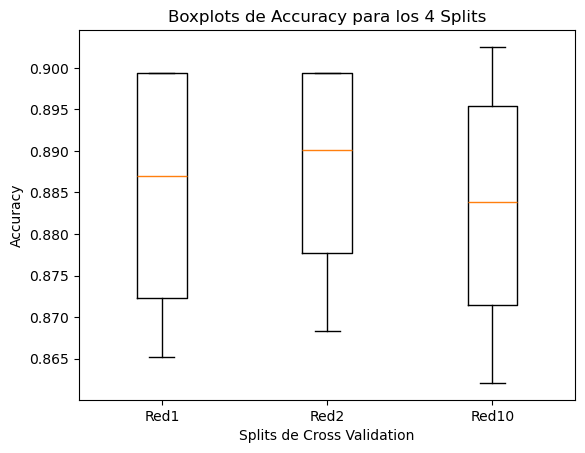

In [39]:
# Crear un boxplot para los cuatro valores de accuracy
plt.boxplot([ac_1.values,ac_2.values,ac_3.values], labels = ['Red1','Red2','Red10'])
plt.title('Boxplots de Accuracy para los 4 Splits')
plt.xlabel('Splits de Cross Validation')
plt.ylabel('Accuracy')
plt.show()